# Regime-Adaptive Defensible Backtest — v3

**Goal:** build a stronger, more defensible version of the Bitcoin DCA model by combining:

- continuous signal transforms instead of hard thresholds
- volatility / downside-risk state features
- interaction terms between valuation, momentum, drawdown, and regime
- adaptive front-loading in strong uptrends
- multi-objective walk-forward tuning instead of one-metric optimisation
- hold-out testing, bootstrap uncertainty, and ablation

**Data used from this repo:** CoinMetrics BTC, MSTR purchases, and Polymarket Fed / ETH signals.

Run the cells **top to bottom**.

---
## Cell 1 — Install dependencies
Only needed the first time. Skip if your environment already has them.

In [ ]:
%pip install pandas numpy matplotlib seaborn --quiet

---
## Cell 2 — Imports and project setup

In [1]:
import sys
import json
import time
import logging
from copy import deepcopy
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from IPython.display import HTML, Markdown, SVG, display

PROJECT_ROOT = Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from template.prelude_template import (
    load_data,
    backtest_dynamic_dca,
    compute_cycle_spd,
    parse_window_dates,
    check_strategy_submission_ready,
)
from template.backtest_template import run_full_analysis, compute_weights_modal
import template.backtest_template as bt
import template.model_development_template as mdt
from template.model_development_template import allocate_sequential_stable, _clean, MIN_W

logging.basicConfig(
    format='%(asctime)s %(levelname)-8s %(message)s',
    level=logging.INFO,
    datefmt='%Y-%m-%d %H:%M:%S',
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 300

THEME = {
    'baseline': '#64748b',
    'accent1':  '#0f766e',
    'accent2':  '#f59e0b',
    'accent3':  '#7c3aed',
    'win':      '#10b981',
    'loss':     '#ef4444',
    'neutral':  '#94a3b8',
}

print(f'Project root : {PROJECT_ROOT}')
print(f'template/ exists : {(PROJECT_ROOT / "template").exists()}')
print(f'data/ exists     : {(PROJECT_ROOT / "data").exists()}')

Project root : D:\Heran Du\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoin\P2_2025_26_ImprovingBitcoinAccumulationStrategies
template/ exists : True
data/ exists     : True


---
## Cell 3 — Load BTC data and attach all available side signals

This cell keeps the repo-compatible loading logic from the earlier notebooks, but also attaches:

- `mvrv` from CoinMetrics `CapMVRVCur`
- a spot-volume activity proxy
- Polymarket Fed / ETH signals
- MSTR purchase amounts

Everything is written to `btc_df` so the later feature-engineering cell can consume it directly.

In [2]:
btc_df = load_data()

raw_csv = PROJECT_ROOT / 'data' / 'Coin Metrics' / 'coinmetrics_btc.csv'
raw = pd.read_csv(raw_csv)
raw['time'] = pd.to_datetime(raw['time'])
raw = raw.set_index('time').sort_index()
raw.index = raw.index.normalize().tz_localize(None)
raw = raw.loc[~raw.index.duplicated(keep='last')]

if 'CapMVRVCur' in raw.columns:
    btc_df['mvrv'] = pd.to_numeric(raw['CapMVRVCur'], errors='coerce').reindex(btc_df.index)
else:
    btc_df['mvrv'] = np.nan

if 'volume_reported_spot_usd_1d' in raw.columns:
    btc_df['spot_volume_usd'] = pd.to_numeric(raw['volume_reported_spot_usd_1d'], errors='coerce').reindex(btc_df.index)
else:
    btc_df['spot_volume_usd'] = np.nan

SIG_DIR = PROJECT_ROOT / 'data' / 'Polymarket' / 'signals'

def _load_signal(filename, col, datefmt=None):
    path = SIG_DIR / filename
    if not path.exists():
        print(f'MISSING: {filename} -- using zeros')
        return pd.Series(dtype=float)
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df['date'] = pd.to_datetime(df['date'], format=datefmt if datefmt else 'mixed', dayfirst=True)
    return pd.to_numeric(df.set_index('date')[col], errors='coerce').fillna(0.0)

fed_raw = _load_signal('fed_signal.csv', 'fed_signal')
eth_bear_raw = _load_signal('eth_bearish.csv', 'eth_bearish_signal')
eth_bull_raw = _load_signal('eth_bullish.csv', 'signal', datefmt='%d/%m/%Y')

poly_fed = fed_raw.resample('D').mean().ffill(limit=3).fillna(0.0).clip(-0.5, 0.5) if not fed_raw.empty else pd.Series(dtype=float)
if not eth_bear_raw.empty or not eth_bull_raw.empty:
    eth_bear_signed = -eth_bear_raw.resample('D').mean().ffill(limit=3).fillna(0.0) if not eth_bear_raw.empty else pd.Series(dtype=float)
    eth_bull_signed = eth_bull_raw.resample('D').mean().ffill(limit=3).fillna(0.0) if not eth_bull_raw.empty else pd.Series(dtype=float)
    poly_eth = pd.concat([eth_bear_signed, eth_bull_signed], axis=1).mean(axis=1).clip(-0.5, 0.5)
else:
    poly_eth = pd.Series(dtype=float)

btc_df['poly_fed_signal'] = poly_fed.reindex(btc_df.index).fillna(0.0)
btc_df['poly_eth_signal'] = poly_eth.reindex(btc_df.index).fillna(0.0)

mstr_path = PROJECT_ROOT / 'data' / 'mstr_buy_signal.csv'
if mstr_path.exists():
    mstr_raw = pd.read_csv(mstr_path)
    mstr_raw['date'] = pd.to_datetime(mstr_raw['purchase_date'], dayfirst=True, format='mixed')
    mstr_daily = mstr_raw.set_index('date')['btc_amount'].groupby(level=0).sum()
    btc_df['mstr_btc_purchased'] = mstr_daily.reindex(btc_df.index).fillna(0.0)
else:
    btc_df['mstr_btc_purchased'] = 0.0

print(f'Rows      : {len(btc_df):,}')
print(f'Date span : {btc_df.index.min().date()} -> {btc_df.index.max().date()}')
print(f'MVRV non-null days      : {btc_df["mvrv"].notna().sum():,}')
print(f'Volume non-null days    : {btc_df["spot_volume_usd"].notna().sum():,}')
print(f'Polymarket Fed non-zero : {(btc_df["poly_fed_signal"] != 0).sum():,}')
print(f'Polymarket ETH non-zero : {(btc_df["poly_eth_signal"] != 0).sum():,}')
print(f'MSTR event days         : {(btc_df["mstr_btc_purchased"] > 0).sum():,}')

btc_df[[
    'PriceUSD_coinmetrics',
    'mvrv',
    'spot_volume_usd',
    'poly_fed_signal',
    'poly_eth_signal',
    'mstr_btc_purchased',
]].tail(5)

2026-05-12 15:05:32 INFO     Loading CoinMetrics BTC data from local file: D:\Heran Du\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoin\P2_2025_26_ImprovingBitcoinAccumulationStrategies\data\Coin Metrics\coinmetrics_btc.csv
2026-05-12 15:05:32 WARNING  Missing BTC-USD prices for 1 dates from 2018-01-01 to 2026-01-14. First missing date: 2026-01-14
2026-05-12 15:05:32 INFO     Loaded CoinMetrics data: 6221 rows, 2009-01-03 to 2026-01-14


Rows      : 6,221
Date span : 2009-01-03 -> 2026-01-14
MVRV non-null days      : 5,659
Volume non-null days    : 5,659
Polymarket Fed non-zero : 241
Polymarket ETH non-zero : 270
MSTR event days         : 94


,PriceUSD_coinmetrics,mvrv,spot_volume_usd,poly_fed_signal,poly_eth_signal,mstr_btc_purchased
time,,,,,,
2026-01-10,90406.142411,1.610013,2.998463e+09,0.0,0.0,0.0
2026-01-11,90717.206315,1.615856,4.399753e+09,0.0,0.0,0.0
2026-01-12,91141.149849,1.623512,1.344799e+10,0.0,0.0,13627.0
2026-01-13,95304.498294,1.695646,1.805277e+10,0.0,0.0,0.0
2026-01-14,NaN,NaN,NaN,0.0,0.0,0.0


---
## Cell 4 — Extend `precompute_features` for v3

This is where most of the model improvement happens.

New feature groups:

- **Valuation:** `mvrv_z`, `mvrv_slope_30`
- **Momentum / regime:** `momentum_30d`, `momentum_90d`, `regime_score`, `trend_strength`
- **Risk state:** `realized_vol_30d`, `downside_vol_30d`, `vol_z`, `dd_speed_30`
- **Cycle state:** `days_since_halving`, `near_ath`
- **Market activity proxy:** `sentiment_proxy`, `volume_z`

All predictive features are lagged one day to stay look-ahead safe.

In [3]:
_ORIG_PRECOMPUTE = mdt.precompute_features

def precompute_features_v3(df):
    base = _ORIG_PRECOMPUTE(df).copy()
    price = base[mdt.PRICE_COL].copy()
    idx = base.index

    ret_1d = price.pct_change()
    ret_7d = price.pct_change(7)
    ret_30d = price.pct_change(30)
    ret_90d = price.pct_change(90)
    ret_180d = price.pct_change(180)

    if 'mvrv' in df.columns:
        mvrv_raw = pd.to_numeric(df['mvrv'], errors='coerce').reindex(idx)
        mvrv_mean = mvrv_raw.rolling(1460, min_periods=180).mean()
        mvrv_std = mvrv_raw.rolling(1460, min_periods=180).std()
        mvrv_z = ((mvrv_raw - mvrv_mean) / mvrv_std).replace([np.inf, -np.inf], np.nan).clip(-4, 4)
        mvrv_slope_30 = mvrv_raw.diff(30) / 30.0
    else:
        mvrv_raw = pd.Series(np.nan, index=idx)
        mvrv_z = pd.Series(0.0, index=idx)
        mvrv_slope_30 = pd.Series(0.0, index=idx)

    realized_vol_30d = ret_1d.rolling(30, min_periods=10).std() * np.sqrt(365)
    downside_vol_30d = ret_1d.clip(upper=0).rolling(30, min_periods=10).std() * np.sqrt(365)
    vol_mean = realized_vol_30d.rolling(365, min_periods=60).mean()
    vol_std = realized_vol_30d.rolling(365, min_periods=60).std()
    vol_z = ((realized_vol_30d - vol_mean) / vol_std).replace([np.inf, -np.inf], np.nan).clip(-4, 4)

    dd_365 = base['dd_365'].copy()
    dd_speed_30 = dd_365.diff(30)
    regime_score = pd.concat([ret_30d, ret_90d, ret_180d], axis=1).mean(axis=1)
    ma200 = price.rolling(200, min_periods=100).mean()
    trend_strength = ((price / ma200) - 1).replace([np.inf, -np.inf], np.nan).clip(-1, 1)
    near_ath = ((price / price.expanding().max()) - 1).replace([np.inf, -np.inf], np.nan).clip(-1, 0)

    if 'spot_volume_usd' in df.columns:
        volume = pd.to_numeric(df['spot_volume_usd'], errors='coerce').reindex(idx)
        log_volume = np.log1p(volume.clip(lower=0))
        volu_mean = log_volume.rolling(365, min_periods=90).mean()
        volu_std = log_volume.rolling(365, min_periods=90).std()
        volume_z = ((log_volume - volu_mean) / volu_std).replace([np.inf, -np.inf], np.nan).clip(-4, 4)
    else:
        volume_z = pd.Series(0.0, index=idx)

    sentiment_proxy = np.tanh(0.8 * ret_7d.fillna(0.0) + 0.4 * volume_z.fillna(0.0))

    halving_dates = pd.to_datetime(['2012-11-28', '2016-07-09', '2020-05-11', '2024-04-20'])
    days_since_halving = pd.Series(np.nan, index=idx)
    for d in idx:
        past = halving_dates[halving_dates <= d]
        days_since_halving.loc[d] = (d - past[-1]).days if len(past) else np.nan

    base['mvrv_z'] = mvrv_z.shift(1).fillna(0.0)
    base['mvrv_slope_30'] = mvrv_slope_30.shift(1).fillna(0.0)
    base['momentum_30d'] = ret_30d.shift(1).fillna(0.0)
    base['momentum_90d'] = ret_90d.shift(1).fillna(0.0)
    base['regime_score'] = regime_score.shift(1).fillna(0.0)
    base['trend_strength'] = trend_strength.shift(1).fillna(0.0)
    base['realized_vol_30d'] = realized_vol_30d.shift(1).fillna(realized_vol_30d.median() if realized_vol_30d.notna().any() else 0.0)
    base['downside_vol_30d'] = downside_vol_30d.shift(1).fillna(downside_vol_30d.median() if downside_vol_30d.notna().any() else 0.0)
    base['vol_z'] = vol_z.shift(1).fillna(0.0)
    base['dd_speed_30'] = dd_speed_30.shift(1).fillna(0.0)
    base['near_ath'] = near_ath.shift(1).fillna(0.0)
    base['days_since_halving'] = days_since_halving.fillna(1000.0)
    base['volume_z'] = volume_z.shift(1).fillna(0.0)
    base['sentiment_proxy'] = sentiment_proxy.shift(1).fillna(0.0)

    return base

mdt.precompute_features = precompute_features_v3
features_df = mdt.precompute_features(btc_df)
bt._FEATURES_DF = features_df

print(f'Features shape : {features_df.shape}')
print(f'Feature columns: {list(features_df.columns)}')
features_df[[
    'price_vs_ma200', 'dd_365', 'mvrv_z', 'mvrv_slope_30', 'momentum_30d',
    'regime_score', 'realized_vol_30d', 'vol_z', 'sentiment_proxy'
]].tail(5)

C:\Users\19741\AppData\Local\Temp\ipykernel_2936\930810593.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret_1d = price.pct_change()
C:\Users\19741\AppData\Local\Temp\ipykernel_2936\930810593.py:9: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret_7d = price.pct_change(7)
C:\Users\19741\AppData\Local\Temp\ipykernel_2936\930810593.py:10: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret_30d = pr

Features shape : (5660, 20)
Feature columns: ['PriceUSD_coinmetrics', 'price_vs_ma200', 'dd_365', 'mstr_signal', 'poly_score', 'cycle_mod', 'mvrv_z', 'mvrv_slope_30', 'momentum_30d', 'momentum_90d', 'regime_score', 'trend_strength', 'realized_vol_30d', 'downside_vol_30d', 'vol_z', 'dd_speed_30', 'near_ath', 'days_since_halving', 'volume_z', 'sentiment_proxy']


,price_vs_ma200,dd_365,mvrv_z,mvrv_slope_30,momentum_30d,regime_score,realized_vol_30d,vol_z,sentiment_proxy
time,,,,,,,,,
2026-01-10,-0.149266,-0.274665,-0.224126,-0.000672,-0.016974,-0.146461,0.272490,-1.142888,-0.015838
2026-01-11,-0.149899,-0.275734,-0.228681,-0.001054,-0.023942,-0.161550,0.271606,-1.144424,-0.791791
2026-01-12,-0.146308,-0.273242,-0.216804,0.000462,0.004269,-0.146160,0.257646,-1.256527,-0.661551
2026-01-13,-0.141678,-0.269845,-0.201406,0.000770,0.009927,-0.139403,0.258067,-1.246096,0.002697
2026-01-14,-0.101971,-0.236492,-0.057892,0.004435,0.081821,-0.087001,0.288045,-0.986605,0.253444


---
## Cell 5 — Quick diagnostic check

Before building the strategy, confirm that the new features exist and that the 2022 problem period is covered.

In [4]:
diag_cols = [
    'mvrv_z', 'mvrv_slope_30', 'momentum_30d', 'regime_score',
    'realized_vol_30d', 'downside_vol_30d', 'vol_z', 'dd_speed_30',
    'sentiment_proxy', 'mstr_signal', 'poly_score'
]
print('Non-zero / non-null coverage:')
for c in diag_cols:
    s = features_df[c]
    print(f'  {c:<18} non-zero={(s != 0).sum():>6,}   non-null={s.notna().sum():>6,}')

fwd30 = btc_df['PriceUSD_coinmetrics'].pct_change(30).shift(-30)
rows = []
for name in ['price_vs_ma200', 'dd_365', 'mvrv_z', 'mvrv_slope_30', 'momentum_30d', 'vol_z', 'sentiment_proxy', 'poly_score']:
    aligned = pd.concat([features_df[name], fwd30], axis=1).dropna()
    corr = aligned.corr().iloc[0, 1] if len(aligned) > 30 else np.nan
    rows.append({'feature': name, 'corr_with_fwd30': corr})
corr_df = pd.DataFrame(rows).sort_values('corr_with_fwd30', ascending=False)
print('\nCorrelation with 30-day forward BTC return:')
print(corr_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

display(features_df.loc['2022', ['mvrv_z', 'momentum_30d', 'vol_z', 'dd_365']].describe().T)

Non-zero / non-null coverage:
  mvrv_z             non-zero= 5,480   non-null= 5,660
  mvrv_slope_30      non-zero= 5,629   non-null= 5,660
  momentum_30d       non-zero= 5,629   non-null= 5,660
  regime_score       non-zero= 5,629   non-null= 5,660
  realized_vol_30d   non-zero= 5,660   non-null= 5,660
  downside_vol_30d   non-zero= 5,660   non-null= 5,660
  vol_z              non-zero= 5,590   non-null= 5,660
  dd_speed_30        non-zero= 5,559   non-null= 5,660
  sentiment_proxy    non-zero= 5,652   non-null= 5,660
  mstr_signal        non-zero= 1,360   non-null= 5,660
  poly_score         non-zero=   270   non-null= 5,660

Correlation with 30-day forward BTC return:
        feature  corr_with_fwd30
   momentum_30d            0.226
 price_vs_ma200            0.216
sentiment_proxy            0.171
         dd_365            0.166
  mvrv_slope_30            0.046
         mvrv_z            0.031
          vol_z            0.019
     poly_score            0.004


C:\Users\19741\AppData\Local\Temp\ipykernel_2936\497516797.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd30 = btc_df['PriceUSD_coinmetrics'].pct_change(30).shift(-30)


,count,mean,std,min,25%,50%,75%,max
mvrv_z,365.0,-0.811864,0.527323,-1.452404,-1.264599,-1.075648,-0.266668,0.234471
momentum_30d,365.0,-0.073354,0.140363,-0.392647,-0.174787,-0.070775,0.026223,0.260162
vol_z,365.0,-0.330977,1.178431,-2.740726,-1.234536,-0.426853,0.588152,2.201016
dd_365,365.0,-0.572721,0.143458,-0.757685,-0.700239,-0.654197,-0.421004,-0.295843


---
## Cell 6 — Define the v3 strategy

Design choices:

1. **Continuous transforms** replace most threshold-based rules.
2. **Falling-knife control** uses momentum and volatility jointly.
3. **Interaction terms** reward cheap-but-stabilising conditions more than cheap-and-chaotic ones.
4. **Adaptive front-loading** happens after weight normalisation, because a constant multiplier inside the raw signal chain gets washed out by the stable allocation logic.

In [5]:
DEFAULT_PARAMS = {
    'spd_alpha': 0.95,
    'spd_scale': 0.14,
    'mvrv_alpha': 0.55,
    'mvrv_scale': 1.00,
    'mvrv_turn_alpha': 0.25,
    'dd_alpha': 1.10,
    'dd_scale': 0.22,
    'dd_power': 1.30,
    'knife_alpha': 0.40,
    'vol_alpha': 0.25,
    'regime_alpha': 0.18,
    'interaction_alpha': 0.25,
    'mstr_alpha': 0.45,
    'poly_alpha': 0.18,
    'sentiment_alpha': 0.10,
    'frontload_max': 0.10,
    'front_days': 60,
}

def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -20, 20)))

def _tanh(x):
    return np.tanh(np.clip(x, -8, 8))

def _safe_clip(arr, lo, hi):
    return np.clip(np.asarray(arr, dtype=float), lo, hi)

def _apply_frontload(weights, intensity, front_days):
    w = np.asarray(weights, dtype=float).copy()
    n = len(w)
    if n < 4 or intensity <= 0:
        return w / w.sum()
    k = int(max(5, min(front_days, n // 3)))
    tail = w[-k:].sum()
    if tail <= 0:
        return w / w.sum()
    shift = min(float(intensity), 0.30) * tail
    tail_weights = w[-k:].copy()
    head_weights = w[:k].copy()
    if tail_weights.sum() > 0:
        w[-k:] = tail_weights * (1.0 - shift / tail_weights.sum())
    if head_weights.sum() > 0:
        w[:k] = head_weights + shift * (head_weights / head_weights.sum())
    else:
        w[:k] = w[:k] + shift / k
    w = np.clip(w, MIN_W, None)
    return w / w.sum()

def compute_weights_v3(df_window, params=None, n_past=None, locked_weights=None):
    params = deepcopy(DEFAULT_PARAMS if params is None else params)
    if df_window.empty:
        return pd.Series(dtype=float)

    df = df_window.copy()
    n = len(df)
    base = np.ones(n) / n

    pma = _clean(df['price_vs_ma200'].values)
    dd = _clean(df['dd_365'].values)
    mvrv_z = _clean(df['mvrv_z'].values)
    mvrv_slope = _clean(df['mvrv_slope_30'].values)
    mom30 = _clean(df['momentum_30d'].values)
    mom90 = _clean(df['momentum_90d'].values)
    regime = _clean(df['regime_score'].values)
    trend = _clean(df['trend_strength'].values)
    vol_z = _clean(df['vol_z'].values)
    down_vol = _clean(df['downside_vol_30d'].values)
    dd_speed = _clean(df['dd_speed_30'].values)
    near_ath = _clean(df['near_ath'].values)
    sentiment = _clean(df['sentiment_proxy'].values)
    mstr = _clean(df['mstr_signal'].values) if 'mstr_signal' in df.columns else np.zeros(n)
    poly = _clean(df['poly_score'].values) if 'poly_score' in df.columns else np.zeros(n)
    days_since_halving = _clean(df['days_since_halving'].values) if 'days_since_halving' in df.columns else np.full(n, 1000.0)

    spd_component = 1.0 + params['spd_alpha'] * _tanh((-pma) / params['spd_scale'])
    cheapness = _tanh((-mvrv_z) / params['mvrv_scale'])
    stabilising_turn = np.maximum(_tanh(mvrv_slope / 0.04), 0.0)
    mvrv_component = 1.0 + params['mvrv_alpha'] * cheapness + params['mvrv_turn_alpha'] * cheapness * stabilising_turn

    depth = np.clip(-dd, 0.0, 0.90)
    dd_component = 1.0 + params['dd_alpha'] * np.power(depth / params['dd_scale'], params['dd_power'])
    dd_component = np.clip(dd_component, 0.6, 3.2)

    falling_knife = _sigmoid((-(mom30 + 0.03)) / 0.04) * _sigmoid((vol_z - 0.25) / 0.60)
    dd_component *= (1.0 - params['knife_alpha'] * falling_knife)

    vol_dampen = 1.0 - params['vol_alpha'] * _sigmoid((vol_z - 0.30) / 0.60)
    downside_dampen = 1.0 - 0.15 * _sigmoid((down_vol - np.nanmedian(down_vol)) / (np.nanstd(down_vol) + 1e-9))

    regime_component = 1.0 + params['regime_alpha'] * _tanh(regime / 0.25)
    interaction_component = 1.0 + params['interaction_alpha'] * cheapness * _tanh((mom90 + regime) / 0.35)
    drawdown_stability = 1.0 + 0.20 * _tanh((-dd_speed) / 0.05) * cheapness
    sentiment_component = 1.0 + params['sentiment_alpha'] * _tanh(-sentiment)

    mstr_component = 1.0 + params['mstr_alpha'] * (np.clip(mstr, 0, None) / (1.0 + np.clip(mstr, 0, None)))
    poly_component = 1.0 + params['poly_alpha'] * np.clip(poly, -1.0, 1.0)

    post_halving_bonus = np.where(days_since_halving < 540, 1.06, 1.00)
    late_cycle_dampen = np.where((days_since_halving > 1000) & (near_ath > -0.10), 0.94, 1.00)

    raw = base
    raw *= spd_component
    raw *= mvrv_component
    raw *= dd_component
    raw *= vol_dampen
    raw *= downside_dampen
    raw *= regime_component
    raw *= interaction_component
    raw *= drawdown_stability
    raw *= sentiment_component
    raw *= mstr_component
    raw *= poly_component
    raw *= post_halving_bonus
    raw *= late_cycle_dampen
    raw = np.clip(raw, MIN_W, None)

    if n_past is None:
        n_past = n
    weights = allocate_sequential_stable(raw, n_past, locked_weights)

    frontload_score = (
        0.35 * _sigmoid((regime - 0.10) / 0.12)
        + 0.25 * _sigmoid((trend - 0.03) / 0.05)
        + 0.20 * _sigmoid((-(vol_z - 0.10)) / 0.50)
        + 0.10 * _sigmoid((-(mvrv_z - 0.80)) / 0.60)
        + 0.10 * _sigmoid((near_ath + 0.18) / 0.05)
    )
    frontload_intensity = params['frontload_max'] * np.clip(frontload_score, 0.0, 1.0)
    weights = _apply_frontload(weights, frontload_intensity.mean(), params['front_days'])

    return pd.Series(weights, index=df.index)

def make_modal_v3(params):
    def _fn(df_window):
        return compute_weights_v3(df_window, params=params)
    return _fn

def make_modal_v3_safe(params, features_lookup):
    def _fn(df_window):
        if df_window.empty:
            return pd.Series(dtype=float)
        if 'price_vs_ma200' not in df_window.columns:
            start = df_window.index.min()
            end = df_window.index.max()
            feat = features_lookup.loc[start:end]
        else:
            feat = df_window
        return compute_weights_v3(feat, params=params)
    return _fn

demo_weights = compute_weights_v3(features_df.loc['2022-01-01':'2023-01-01'], params=DEFAULT_PARAMS)
print(f'Weight sum demo: {demo_weights.sum():.8f}')
print(f'Min / Max      : {demo_weights.min():.6f} / {demo_weights.max():.6f}')

Weight sum demo: 1.00000000
Min / Max      : 0.001267 / 0.003982


---
## Cell 7 — Baseline reproduction and evaluation helpers

We reproduce the baseline first so every later comparison stays apples-to-apples.

In [8]:
mdt.precompute_features = _ORIG_PRECOMPUTE
features_baseline = _ORIG_PRECOMPUTE(btc_df)
bt._FEATURES_DF = features_baseline
baseline_full_tbl, baseline_full_exp = backtest_dynamic_dca(
    btc_df,
    compute_weights_modal,
    features_df=features_baseline,
    strategy_label='Baseline',
)

mdt.precompute_features = precompute_features_v3
bt._FEATURES_DF = features_df

def summarize_table(tbl):
    excess = tbl['dynamic_percentile'] - tbl['uniform_percentile']
    N = len(tbl)
    exp_w = 0.9 ** np.arange(N - 1, -1, -1)
    exp_w = exp_w / exp_w.sum()
    exp_pct = float((tbl['dynamic_percentile'].values * exp_w).sum())
    win_rate = float((excess > 0).mean() * 100)
    score = 0.5 * win_rate + 0.5 * exp_pct
    return {
        'score': score,
        'win_rate': win_rate,
        'exp_pct': exp_pct,
        'mean_excess': float(excess.mean()),
        'median_excess': float(excess.median()),
        'n_windows': int(N),
        'tbl': tbl,
    }

def evaluate_range(params, start_date, end_date, use_v3=True):
    fn = make_modal_v3(params) if use_v3 else compute_weights_modal
    feat = features_df if use_v3 else features_baseline
    try:
        tbl = compute_cycle_spd(
            btc_df,
            fn,
            features_df=feat,
            start_date=start_date,
            end_date=end_date,
            validate_weights=False,
        )
    except KeyError as e:
        if "window" in str(e):
            tbl = pd.DataFrame()
        else:
            raise

    if tbl is None or tbl.empty:
        return {
            'score': -999.0,
            'win_rate': 0.0,
            'exp_pct': 0.0,
            'mean_excess': -999.0,
            'median_excess': -999.0,
            'n_windows': 0,
            'tbl': pd.DataFrame(),
        }

    return summarize_table(tbl)

TRAIN_FOLDS = [
    ('2018-01-01', '2020-12-31'),
    ('2019-01-01', '2021-12-31'),
    ('2020-01-01', '2022-12-31'),
    ('2021-01-01', '2023-12-31'),
]
# The backtest uses 1-year rolling windows, so a "2022 stress" slice must
# extend into 2023 in order to include windows that start during 2022.
YEAR_2022 = ('2022-01-01', '2023-12-31')
HOLDOUT = ('2024-01-01', '2025-12-31')
FULL = ('2018-01-01', '2025-12-31')

def composite_objective(params):
    fold_results = [evaluate_range(params, s, e, use_v3=True) for s, e in TRAIN_FOLDS]
    stress = evaluate_range(params, *YEAR_2022, use_v3=True)
    mean_fold_score = float(np.mean([r['score'] for r in fold_results]))
    worst_fold_score = float(np.min([r['score'] for r in fold_results]))
    mean_fold_exp = float(np.mean([r['exp_pct'] for r in fold_results]))
    stress_score = 0.5 * stress['win_rate'] + 0.5 * max(0.0, 50.0 + 10.0 * stress['mean_excess'])
    objective = 0.45 * mean_fold_score + 0.25 * worst_fold_score + 0.15 * mean_fold_exp + 0.15 * stress_score
    return {
        'objective': objective,
        'mean_fold_score': mean_fold_score,
        'worst_fold_score': worst_fold_score,
        'mean_fold_exp': mean_fold_exp,
        'stress_2022_score': stress['score'],
        'stress_2022_win_rate': stress['win_rate'],
        'stress_2022_mean_excess': stress['mean_excess'],
    }

baseline_full = summarize_table(baseline_full_tbl)
baseline_holdout = evaluate_range(DEFAULT_PARAMS, *HOLDOUT, use_v3=False)
print(f'Baseline full score   : {baseline_full["score"]:.2f}%')
print(f'Baseline holdout score: {baseline_holdout["score"]:.2f}%')

2026-05-12 15:12:42 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)
2026-05-12 15:13:24 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)
2026-05-12 15:13:24 INFO     Aggregated Metrics for Baseline:
2026-05-12 15:13:24 INFO       SPD: min=1004.68, max=19778.55, mean=6679.89, median=3964.50
2026-05-12 15:13:24 INFO       Percentile: min=19.76%, max=68.69%, mean=39.74%, median=39.73%
2026-05-12 15:13:24 INFO       Exp-decay avg SPD percentile: 42.89%
2026-05-12 15:13:24 INFO     Backtesting date range: 2024-01-01 to 2025-12-31 (366 total windows)


Baseline full score   : 53.18%
Baseline holdout score: 64.61%


---
## Cell 8 — Multi-objective random search on the training folds only

This search does **not** see the 2024–2025 hold-out block. The objective rewards:

- strong average fold score
- a better worst fold
- higher recent-percentile behaviour inside training
- better 2022 stress handling

**Runtime:** roughly 10–25 minutes depending on hardware and the number of trials.

In [10]:
rng = np.random.default_rng(42)
N_TRIALS = 20

def sample_params():
    p = deepcopy(DEFAULT_PARAMS)
    p.update({
        'spd_alpha': float(rng.uniform(0.50, 1.40)),
        'spd_scale': float(rng.choice([0.08, 0.10, 0.12, 0.14, 0.18])),
        'mvrv_alpha': float(rng.uniform(0.00, 0.90)),
        'mvrv_scale': float(rng.choice([0.75, 1.00, 1.25, 1.50])),
        'mvrv_turn_alpha': float(rng.choice([0.0, 0.15, 0.25, 0.35, 0.45])),
        'dd_alpha': float(rng.uniform(0.40, 1.80)),
        'dd_scale': float(rng.choice([0.16, 0.20, 0.24, 0.28])),
        'dd_power': float(rng.choice([1.00, 1.20, 1.40, 1.60])),
        'knife_alpha': float(rng.choice([0.0, 0.20, 0.40, 0.60])),
        'vol_alpha': float(rng.choice([0.0, 0.10, 0.25, 0.40])),
        'regime_alpha': float(rng.choice([0.0, 0.10, 0.18, 0.28, 0.38])),
        'interaction_alpha': float(rng.choice([0.0, 0.15, 0.25, 0.35, 0.45])),
        'mstr_alpha': float(rng.choice([0.20, 0.35, 0.50, 0.65])),
        'poly_alpha': float(rng.choice([0.0, 0.10, 0.18, 0.25, 0.35])),
        'sentiment_alpha': float(rng.choice([0.0, 0.05, 0.10, 0.15, 0.20])),
        'frontload_max': float(rng.choice([0.0, 0.06, 0.10, 0.14, 0.18])),
        'front_days': int(rng.choice([30, 45, 60, 75, 90])),
    })
    return p

trial_results = []
best_params = deepcopy(DEFAULT_PARAMS)
best_obj = -np.inf

t0 = time.time()
print(f'Running {N_TRIALS} trials...')
print('Progress: ', end='', flush=True)
tick = max(N_TRIALS // 20, 1)

for i in range(N_TRIALS):
    p = sample_params()
    metrics = composite_objective(p)
    row = {**p, **metrics}
    trial_results.append(row)
    if metrics['objective'] > best_obj:
        best_obj = metrics['objective']
        best_params = deepcopy(p)
    if (i + 1) % tick == 0:
        print(f'{(i + 1) / N_TRIALS * 100:.0f}%', end=' ', flush=True)

trial_results = pd.DataFrame(trial_results).sort_values('objective', ascending=False).reset_index(drop=True)
elapsed = time.time() - t0

print(f'\nDone in {elapsed/60:.1f} minutes')
print(f'Best composite objective: {best_obj:.3f}')
print('Best params:')
for k, v in best_params.items():
    print(f'  {k:<18} {v}')

trial_results.head(10)

Running 20 trials...
Progress: 

2026-05-12 15:42:51 INFO     Backtesting date range: 2018-01-01 to 2020-12-31 (730 total windows)


2026-05-12 15:43:04 INFO     Backtesting date range: 2019-01-01 to 2021-12-31 (731 total windows)
2026-05-12 15:43:17 INFO     Backtesting date range: 2020-01-01 to 2022-12-31 (731 total windows)
2026-05-12 15:43:30 INFO     Backtesting date range: 2021-01-01 to 2023-12-31 (730 total windows)
2026-05-12 15:43:42 INFO     Backtesting date range: 2022-01-01 to 2023-12-31 (365 total windows)


5% 

2026-05-12 15:43:49 INFO     Backtesting date range: 2018-01-01 to 2020-12-31 (730 total windows)
2026-05-12 15:44:02 INFO     Backtesting date range: 2019-01-01 to 2021-12-31 (731 total windows)
2026-05-12 15:44:14 INFO     Backtesting date range: 2020-01-01 to 2022-12-31 (731 total windows)
2026-05-12 15:44:27 INFO     Backtesting date range: 2021-01-01 to 2023-12-31 (730 total windows)
2026-05-12 15:44:40 INFO     Backtesting date range: 2022-01-01 to 2023-12-31 (365 total windows)


...

2026-05-12 15:59:56 INFO     Backtesting date range: 2018-01-01 to 2020-12-31 (730 total windows)
2026-05-12 16:00:08 INFO     Backtesting date range: 2019-01-01 to 2021-12-31 (731 total windows)
2026-05-12 16:00:21 INFO     Backtesting date range: 2020-01-01 to 2022-12-31 (731 total windows)
2026-05-12 16:00:34 INFO     Backtesting date range: 2021-01-01 to 2023-12-31 (730 total windows)
2026-05-12 16:00:46 INFO     Backtesting date range: 2022-01-01 to 2023-12-31 (365 total windows)


95% 

2026-05-12 16:00:52 INFO     Backtesting date range: 2018-01-01 to 2020-12-31 (730 total windows)
2026-05-12 16:01:05 INFO     Backtesting date range: 2019-01-01 to 2021-12-31 (731 total windows)
2026-05-12 16:01:18 INFO     Backtesting date range: 2020-01-01 to 2022-12-31 (731 total windows)
2026-05-12 16:01:29 INFO     Backtesting date range: 2021-01-01 to 2023-12-31 (730 total windows)
2026-05-12 16:01:40 INFO     Backtesting date range: 2022-01-01 to 2023-12-31 (365 total windows)


100% 
Done in 18.9 minutes
Best composite objective: 42.526
Best params:
  spd_alpha          1.196560443700367
  spd_scale          0.14
  mvrv_alpha         0.7727381279202442
  mvrv_scale         1.0
  mvrv_turn_alpha    0.0
  dd_alpha           0.5318482870427094
  dd_scale           0.24
  dd_power           1.4
  knife_alpha        0.6
  vol_alpha          0.25
  regime_alpha       0.28
  interaction_alpha  0.35
  mstr_alpha         0.65
  poly_alpha         0.18
  sentiment_alpha    0.0
  frontload_max      0.18
  front_days         60


,spd_alpha,spd_scale,mvrv_alpha,mvrv_scale,mvrv_turn_alpha,dd_alpha,dd_scale,dd_power,knife_alpha,vol_alpha,...,sentiment_alpha,frontload_max,front_days,objective,mean_fold_score,worst_fold_score,mean_fold_exp,stress_2022_score,stress_2022_win_rate,stress_2022_mean_excess
0,1.196560,0.14,0.772738,1.00,0.00,0.531848,0.24,1.4,0.6,0.25,...,0.00,0.18,60,42.525662,44.673500,36.469667,35.407707,46.120068,62.191781,-0.560493
1,1.097882,0.12,0.732618,1.00,0.15,0.431797,0.16,1.0,0.0,0.40,...,0.00,0.18,60,42.115297,44.854855,37.758556,36.284537,42.455064,52.328767,-0.835153
2,0.596967,0.14,0.207193,1.50,0.15,1.176793,0.16,1.4,0.2,0.10,...,0.05,0.06,90,41.056825,42.271136,39.286816,36.729508,37.201748,42.191781,-0.280933
3,0.679917,0.18,0.708232,0.75,0.35,1.387232,0.24,1.2,0.6,0.25,...,0.00,0.06,30,39.844861,41.929084,37.734117,35.531894,36.379774,42.465753,-0.961962
4,0.653534,0.10,0.522955,1.50,0.25,1.227282,0.20,1.2,0.0,0.00,...,0.15,0.00,30,39.775318,42.139045,37.402931,35.541418,37.606196,45.205479,-1.346145
5,1.243663,0.08,0.126224,1.50,0.15,0.552006,0.24,1.4,0.4,0.00,...,0.15,0.18,75,39.245200,42.988612,36.539772,35.564672,35.145632,39.726027,-1.731695
6,1.182279,0.14,0.873628,1.00,0.25,1.489737,0.28,1.6,0.0,0.10,...,0.00,0.14,75,39.088142,43.245711,40.764365,36.009956,30.007977,29.315068,-2.551524
7,0.910199,0.14,0.275361,0.75,0.45,0.647482,0.24,1.2,0.6,0.00,...,0.10,0.06,75,38.966434,42.031458,35.579485,35.121139,36.856486,44.931507,-1.640836
8,0.693126,0.10,0.768063,1.00,0.00,0.481624,0.16,1.6,0.2,0.40,...,0.10,0.10,75,38.965709,42.056277,37.696039,35.034167,32.770669,36.986301,-1.550298
9,0.761826,0.14,0.230369,1.25,0.45,0.630451,0.28,1.4,0.0,0.10,...,0.20,0.00,75,38.745005,42.543791,36.216774,35.496245,34.225227,40.821918,-2.119967


---
## Cell 9 — Evaluate the tuned v3 model on the hold-out block and on the full sample

In [11]:
v3_train_folds = [evaluate_range(best_params, s, e, use_v3=True) for s, e in TRAIN_FOLDS]
v3_holdout = evaluate_range(best_params, *HOLDOUT, use_v3=True)
v3_full = evaluate_range(best_params, *FULL, use_v3=True)
v3_2022 = evaluate_range(best_params, *YEAR_2022, use_v3=True)

baseline_2022 = evaluate_range(best_params, *YEAR_2022, use_v3=False)
baseline_full = evaluate_range(best_params, *FULL, use_v3=False)

print('=' * 90)
print('V3 VS BASELINE')
print('=' * 90)
print(f'{"Segment":<18} {"Baseline":>12} {"V3":>12} {"Delta":>12}')
print('-' * 90)
for label, base_res, v3_res in [
    ('2022 stress', baseline_2022, v3_2022),
    ('2024-2025 holdout', baseline_holdout, v3_holdout),
    ('2018-2025 full', baseline_full, v3_full),
]:
    delta = v3_res['score'] - base_res['score']
    print(f'{label:<18} {base_res["score"]:>11.2f}% {v3_res["score"]:>11.2f}% {delta:>+11.2f}pp')

print('\nTraining-fold scores:')
for (s, e), res in zip(TRAIN_FOLDS, v3_train_folds):
    print(f'  {s} -> {e}  score={res["score"]:.2f}%  win_rate={res["win_rate"]:.2f}%  mean_excess={res["mean_excess"]:.2f}pp')

2026-05-12 16:01:46 INFO     Backtesting date range: 2018-01-01 to 2020-12-31 (730 total windows)
2026-05-12 16:01:59 INFO     Backtesting date range: 2019-01-01 to 2021-12-31 (731 total windows)
2026-05-12 16:02:12 INFO     Backtesting date range: 2020-01-01 to 2022-12-31 (731 total windows)
2026-05-12 16:02:24 INFO     Backtesting date range: 2021-01-01 to 2023-12-31 (730 total windows)
2026-05-12 16:02:37 INFO     Backtesting date range: 2024-01-01 to 2025-12-31 (366 total windows)
2026-05-12 16:02:44 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)
2026-05-12 16:03:29 INFO     Backtesting date range: 2022-01-01 to 2023-12-31 (365 total windows)
2026-05-12 16:03:35 INFO     Backtesting date range: 2022-01-01 to 2023-12-31 (365 total windows)
2026-05-12 16:03:41 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)


V3 VS BASELINE
Segment                Baseline           V3        Delta
------------------------------------------------------------------------------------------
2022 stress              26.79%       46.12%      +19.33pp
2024-2025 holdout        64.61%       80.13%      +15.52pp
2018-2025 full           53.18%       60.73%       +7.55pp

Training-fold scores:
  2018-01-01 -> 2020-12-31  score=36.47%  win_rate=49.45%  mean_excess=-0.61pp
  2019-01-01 -> 2021-12-31  score=45.79%  win_rate=47.88%  mean_excess=-2.29pp
  2020-01-01 -> 2022-12-31  score=46.89%  win_rate=49.38%  mean_excess=0.76pp
  2021-01-01 -> 2023-12-31  score=49.54%  win_rate=69.04%  mean_excess=3.26pp


---
## Cell 10 — Bootstrap uncertainty and yearly breakdown

We estimate whether the hold-out gain is stable, then inspect the yearly pattern to confirm whether the model improved the troublesome regimes instead of just inflating one lucky segment.

Hold-out block bootstrap 95% CI:
  Baseline: 63.19%  [51.53, 73.01]
  V3      : 76.69%  [67.77, 85.16]
  Delta   : +13.50pp [+5.33, +23.17]

Year-by-year breakdown:
     Baseline                                     V3                                  
            n win_rate mean_excess mean_dyn_pct    n win_rate mean_excess mean_dyn_pct
year                                                                                  
2018      365    70.41        0.58        41.90  365    26.03       -2.19        39.14
2019      365    66.03        1.39        33.22  365    72.88        0.96        32.80
2020      366    46.17       -0.12        34.07  366    22.95       -5.53        28.66
2021      365   100.00        5.06        43.59  365    75.89        7.08        45.61
2022      365    20.82       -2.67        41.67  365    62.19       -0.56        43.79
2023      365    54.52        0.35        42.84  365    66.85       12.00        54.49
2024      366    86.34        2.69        40.89  366

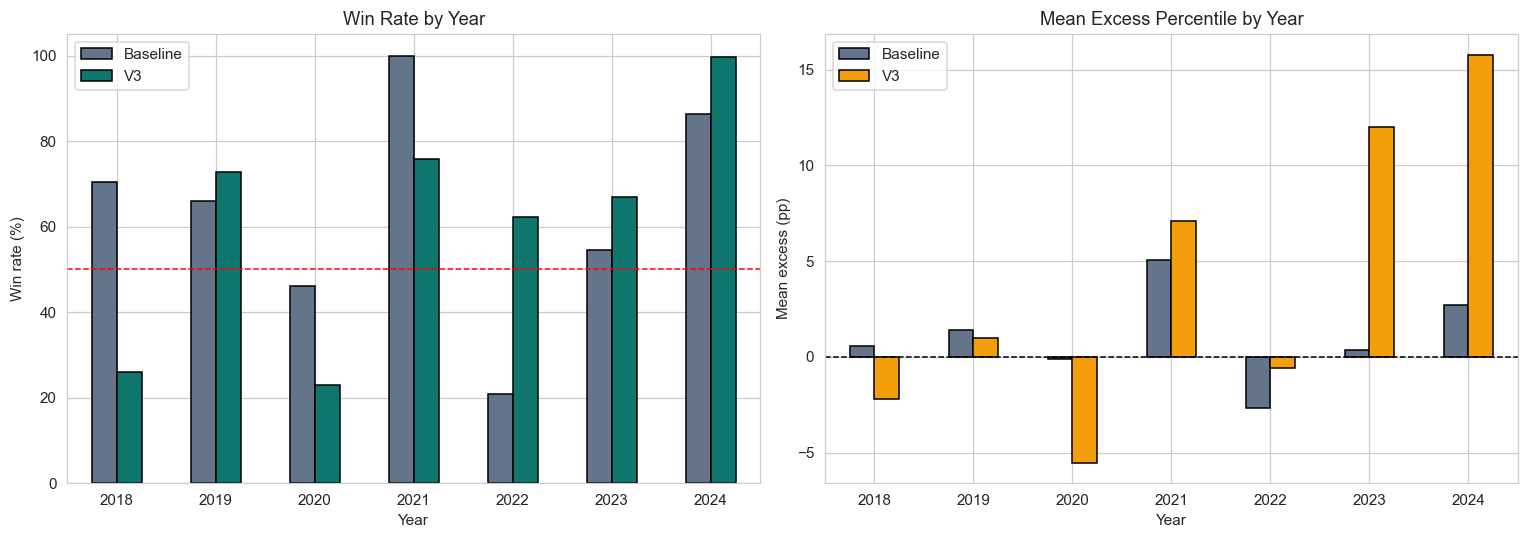

In [12]:
def block_bootstrap_score(tbl, n_boot=800, block_size=30, seed=42):
    rng = np.random.default_rng(seed)
    dyn = tbl['dynamic_percentile'].values
    uni = tbl['uniform_percentile'].values
    N = len(tbl)
    n_blocks = N // block_size + 1
    out = []
    for _ in range(n_boot):
        starts = rng.integers(0, N - block_size + 1, size=n_blocks)
        idx = np.concatenate([np.arange(s, s + block_size) for s in starts])[:N]
        d = dyn[idx]
        u = uni[idx]
        exp_w = 0.9 ** np.arange(N - 1, -1, -1)
        exp_w = exp_w / exp_w.sum()
        win_rate = (d > u).mean() * 100
        exp_pct = float((d * exp_w).sum())
        out.append(0.5 * win_rate + 0.5 * exp_pct)
    return np.array(out)

bs_base = block_bootstrap_score(baseline_holdout['tbl'])
bs_v3 = block_bootstrap_score(v3_holdout['tbl'])
ci_base = np.percentile(bs_base, [2.5, 97.5])
ci_v3 = np.percentile(bs_v3, [2.5, 97.5])
diff = bs_v3 - bs_base
ci_diff = np.percentile(diff, [2.5, 97.5])

print('Hold-out block bootstrap 95% CI:')
print(f'  Baseline: {bs_base.mean():.2f}%  [{ci_base[0]:.2f}, {ci_base[1]:.2f}]')
print(f'  V3      : {bs_v3.mean():.2f}%  [{ci_v3[0]:.2f}, {ci_v3[1]:.2f}]')
print(f'  Delta   : {diff.mean():+.2f}pp [{ci_diff[0]:+.2f}, {ci_diff[1]:+.2f}]')

def yearly_breakdown(tbl, label):
    d = tbl.copy()
    d['date'] = d.index.map(parse_window_dates)
    d['year'] = pd.to_datetime(d['date']).dt.year
    d['excess'] = d['dynamic_percentile'] - d['uniform_percentile']
    g = d.groupby('year').agg(
        n=('excess', 'count'),
        win_rate=('excess', lambda x: (x > 0).mean() * 100),
        mean_excess=('excess', 'mean'),
        mean_dyn_pct=('dynamic_percentile', 'mean'),
    )
    g.columns = pd.MultiIndex.from_product([[label], g.columns])
    return g

yr_base = yearly_breakdown(baseline_full['tbl'], 'Baseline')
yr_v3 = yearly_breakdown(v3_full['tbl'], 'V3')
yr = pd.concat([yr_base, yr_v3], axis=1)
print('\nYear-by-year breakdown:')
print(yr.to_string(float_format=lambda x: f'{x:.2f}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pd.DataFrame({
    'Baseline': yr_base[('Baseline', 'win_rate')],
    'V3': yr_v3[('V3', 'win_rate')],
}).plot(kind='bar', ax=axes[0], color=[THEME['baseline'], THEME['accent1']], edgecolor='black')
axes[0].axhline(50, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Win Rate by Year')
axes[0].set_ylabel('Win rate (%)')
axes[0].set_xlabel('Year')
axes[0].tick_params(axis='x', rotation=0)

pd.DataFrame({
    'Baseline': yr_base[('Baseline', 'mean_excess')],
    'V3': yr_v3[('V3', 'mean_excess')],
}).plot(kind='bar', ax=axes[1], color=[THEME['baseline'], THEME['accent2']], edgecolor='black')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Mean Excess Percentile by Year')
axes[1].set_ylabel('Mean excess (pp)')
axes[1].set_xlabel('Year')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

---
## Cell 11 — Ablation: which v3 components matter most?

2026-05-12 16:04:27 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)
2026-05-12 16:05:12 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)
2026-05-12 16:05:56 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)
2026-05-12 16:06:41 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)
2026-05-12 16:07:25 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)
2026-05-12 16:08:09 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)


             component  score  win_rate  exp_pct  mean_excess  delta_vs_full
               Full v3 60.735    60.931   60.539        3.936          0.000
               No MVRV 58.033    56.629   59.438        3.161         -2.701
No vol / knife control 60.943    60.149   61.736        4.419          0.208
       No interactions 60.009    59.640   60.377        4.327         -0.726
         No front-load 57.792    54.830   60.753        2.346         -2.943
      No event signals 60.118    59.875   60.362        3.922         -0.616


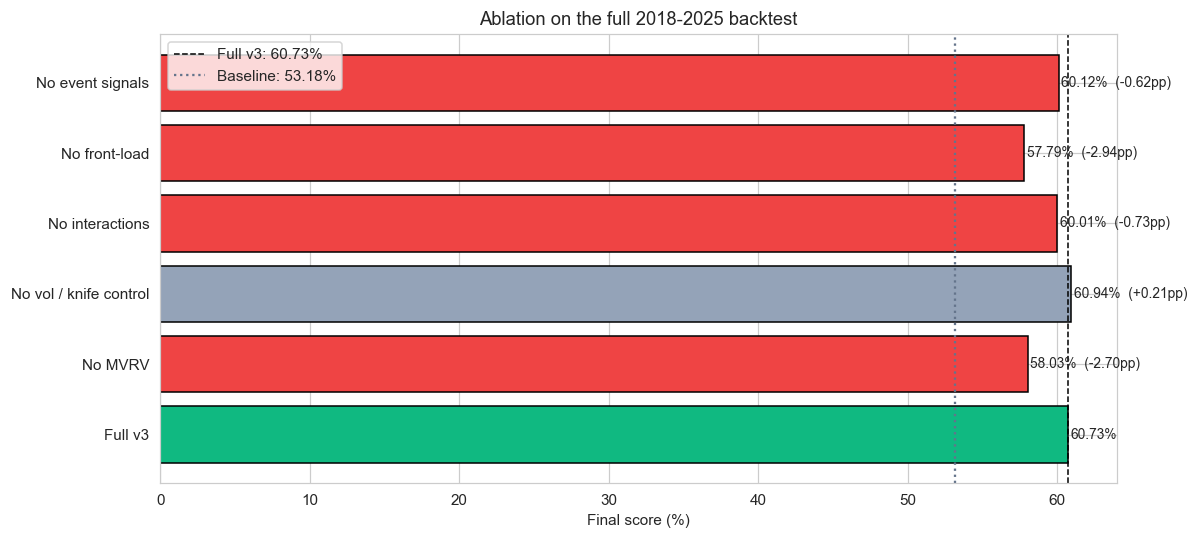

In [13]:
ablation_configs = [
    ('Full v3', {}),
    ('No MVRV', {'mvrv_alpha': 0.0, 'mvrv_turn_alpha': 0.0}),
    ('No vol / knife control', {'vol_alpha': 0.0, 'knife_alpha': 0.0}),
    ('No interactions', {'interaction_alpha': 0.0, 'regime_alpha': 0.0}),
    ('No front-load', {'frontload_max': 0.0}),
    ('No event signals', {'mstr_alpha': 0.0, 'poly_alpha': 0.0}),
]

ablation_rows = []
for name, overrides in ablation_configs:
    p = deepcopy(best_params)
    p.update(overrides)
    res = evaluate_range(p, *FULL, use_v3=True)
    ablation_rows.append({
        'component': name,
        'score': res['score'],
        'win_rate': res['win_rate'],
        'exp_pct': res['exp_pct'],
        'mean_excess': res['mean_excess'],
    })

ab_df = pd.DataFrame(ablation_rows)
ab_df['delta_vs_full'] = ab_df['score'] - ab_df.iloc[0]['score']
print(ab_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

fig, ax = plt.subplots(figsize=(11, 5))
colors = [THEME['win'] if i == 0 else (THEME['loss'] if d < 0 else THEME['neutral']) for i, d in enumerate(ab_df['delta_vs_full'])]
bars = ax.barh(ab_df['component'], ab_df['score'], color=colors, edgecolor='black')
ax.axvline(ab_df.iloc[0]['score'], color='black', linestyle='--', linewidth=1, label=f'Full v3: {ab_df.iloc[0]["score"]:.2f}%')
ax.axvline(baseline_full['score'], color=THEME['baseline'], linestyle=':', linewidth=1.5, label=f'Baseline: {baseline_full["score"]:.2f}%')
ax.set_xlabel('Final score (%)')
ax.set_title('Ablation on the full 2018-2025 backtest')
for bar, score, delta in zip(bars, ab_df['score'], ab_df['delta_vs_full']):
    label = f'{score:.2f}%'
    if delta != 0:
        label += f'  ({delta:+.2f}pp)'
    ax.text(score + 0.15, bar.get_y() + bar.get_height()/2, label, va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

---
## Cell 12 — Save outputs and run the standard full-analysis pipeline

This produces the usual repo-style artifacts plus a v3-specific summary package.

In [15]:
OUTPUT_DIR = PROJECT_ROOT / 'output_v3_regime_adaptive'
OUTPUT_DIR.mkdir(exist_ok=True)

# More robust than the earlier wrapper: run_full_analysis() internally calls
# validation helpers that may regenerate an older feature set. If any required
# v3 columns are missing, always fall back to the precomputed v3 features.
REQUIRED_V3_COLS = {
    'price_vs_ma200', 'dd_365', 'mvrv_z', 'mvrv_slope_30', 'momentum_30d',
    'momentum_90d', 'regime_score', 'trend_strength', 'downside_vol_30d',
    'vol_z', 'dd_speed_30', 'near_ath', 'sentiment_proxy', 'days_since_halving'
}

def best_modal_safe(df_window):
    if df_window.empty:
        return pd.Series(dtype=float)

    use_lookup = True
    if isinstance(df_window, pd.DataFrame):
        use_lookup = not REQUIRED_V3_COLS.issubset(set(df_window.columns))

    if use_lookup:
        start = df_window.index.min()
        end = df_window.index.max()
        feat = features_df.loc[start:end]
    else:
        feat = df_window

    return compute_weights_v3(feat, params=best_params)

run_full_analysis(
    btc_df=btc_df,
    features_df=features_df,
    compute_weights_fn=best_modal_safe,
    output_dir=OUTPUT_DIR,
    strategy_label='Regime-Adaptive v3',
)

trial_results.to_csv(OUTPUT_DIR / 'random_search_trials.csv', index=False)
ab_df.to_csv(OUTPUT_DIR / 'ablation.csv', index=False)

def prep(tbl):
    d = tbl.copy()
    d['date'] = d.index.map(parse_window_dates)
    return d.sort_values('date')

b_full = prep(baseline_full['tbl'])
v_full = prep(v3_full['tbl'])

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(b_full['date'], b_full['dynamic_percentile'], color=THEME['baseline'], linewidth=1.8, label='Baseline')
ax.plot(v_full['date'], v_full['dynamic_percentile'], color=THEME['accent1'], linewidth=2.1, label='V3')
ax.plot(v_full['date'], v_full['uniform_percentile'], color=THEME['accent2'], linewidth=1.2, linestyle='--', label='Uniform')
ax.set_title('Dynamic Percentile Through Time')
ax.set_ylabel('SPD percentile (%)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'v3_vs_baseline_percentiles.svg', format='svg', bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(bs_base, fill=True, color=THEME['baseline'], alpha=0.35, label='Baseline', ax=ax)
sns.kdeplot(bs_v3, fill=True, color=THEME['accent1'], alpha=0.35, label='V3', ax=ax)
ax.axvline(bs_base.mean(), color=THEME['baseline'], linestyle='--')
ax.axvline(bs_v3.mean(), color=THEME['accent1'], linestyle='--')
ax.set_title('Hold-out Bootstrap Score Distribution')
ax.set_xlabel('Score (%)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'holdout_bootstrap.svg', format='svg', bbox_inches='tight')
plt.close()

summary = {
    'timestamp': datetime.now().isoformat(),
    'train_folds': TRAIN_FOLDS,
    'holdout': HOLDOUT,
    'baseline': {
        'full': {k: float(v) for k, v in baseline_full.items() if k != 'tbl'},
        'holdout': {k: float(v) for k, v in baseline_holdout.items() if k != 'tbl'},
        'stress_2022': {k: float(v) for k, v in baseline_2022.items() if k != 'tbl'},
    },
    'v3': {
        'full': {k: float(v) for k, v in v3_full.items() if k != 'tbl'},
        'holdout': {k: float(v) for k, v in v3_holdout.items() if k != 'tbl'},
        'stress_2022': {k: float(v) for k, v in v3_2022.items() if k != 'tbl'},
    },
    'bootstrap_holdout': {
        'baseline_mean': float(bs_base.mean()),
        'baseline_ci95': [float(ci_base[0]), float(ci_base[1])],
        'v3_mean': float(bs_v3.mean()),
        'v3_ci95': [float(ci_v3[0]), float(ci_v3[1])],
        'delta_ci95': [float(ci_diff[0]), float(ci_diff[1])],
    },
    'best_params': {k: (float(v) if isinstance(v, (int, float, np.floating)) else v) for k, v in best_params.items()},
}
with open(OUTPUT_DIR / 'v3_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f'All v3 outputs saved to: {OUTPUT_DIR}')

2026-05-12 16:16:32 INFO     Running SPD backtest for 'Regime-Adaptive v3'...
2026-05-12 16:16:32 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)


2026-05-12 16:17:17 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)
2026-05-12 16:17:17 INFO     Aggregated Metrics for Regime-Adaptive v3:
2026-05-12 16:17:17 INFO       SPD: min=1106.33, max=19974.71, mean=6546.96, median=3946.77
2026-05-12 16:17:17 INFO       Percentile: min=15.17%, max=89.23%, mean=42.64%, median=39.02%
2026-05-12 16:17:17 INFO       Exp-decay avg SPD percentile: 60.54%
2026-05-12 16:17:17 INFO     Running strategy validation...


Validating strategy submission readiness...


2026-05-12 16:18:20 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)
2026-05-12 16:19:05 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)



⚠️ Windows where strategy underperformed Uniform DCA:


,dynamic_percentile,uniform_percentile,Delta
window,,,
2018-01-01 → 2019-01-01,30.891227,34.917062,-4.025835
2018-01-02 → 2019-01-02,31.010308,35.111968,-4.101660
2018-01-03 → 2019-01-03,31.148447,35.322066,-4.173618
2018-01-04 → 2019-01-04,31.279798,35.530215,-4.250417
2018-01-05 → 2019-01-05,31.423741,35.740775,-4.317033
...,...,...,...
2023-12-08 → 2024-12-08,43.722052,44.362646,-0.640593
2023-12-09 → 2024-12-09,43.686296,44.143299,-0.457003
2023-12-10 → 2024-12-10,43.647280,43.920727,-0.273447


2026-05-12 16:19:05 INFO     Final Model Score: 60.73%
2026-05-12 16:19:05 INFO       Excess percentile: mean=3.94%, median=2.43%
2026-05-12 16:19:05 INFO       Relative improvement: mean=9.21%, median=5.85%
2026-05-12 16:19:05 INFO       Ratio (dynamic/uniform): mean=1.09, median=1.06
2026-05-12 16:19:05 INFO     Generating visualizations...



Summary: 999/2557 underperformed (60.93% win rate)
✅ Strategy meets performance requirement (≥ 50% win rate vs. uniform DCA).

✅ Strategy is ready for submission.


2026-05-12 16:19:07 INFO     ✓ Saved: D:\Heran Du\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoin\P2_2025_26_ImprovingBitcoinAccumulationStrategies\output_v3_regime_adaptive\performance_comparison.svg
2026-05-12 16:19:08 INFO     ✓ Saved: D:\Heran Du\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoin\P2_2025_26_ImprovingBitcoinAccumulationStrategies\output_v3_regime_adaptive\excess_percentile_distribution.svg
2026-05-12 16:19:08 INFO     ✓ Saved: D:\Heran Du\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoin\P2_2025_26_ImprovingBitcoinAccumulationStrategies\output_v3_regime_adaptive\win_loss_comparison.svg
2026-05-12 16:19:10 INFO     ✓ Saved: D:\Heran Du\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoin\P2_2025_26_ImprovingBitcoinAccumulationStrategies\output_v3_regime_adaptive\cumulative_performance.svg
2026-05-12 16:19:11 INF

All v3 outputs saved to: D:\Heran Du\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoin\P2_2025_26_ImprovingBitcoinAccumulationStrategies\output_v3_regime_adaptive


---
## Cell 13 — Final summary card

In [16]:
holdout_delta = v3_holdout['score'] - baseline_holdout['score']
full_delta = v3_full['score'] - baseline_full['score']
significant = ci_diff[0] > 0
verdict = 'Hold-out improvement is statistically persuasive' if significant else 'Hold-out improvement is positive but not clearly significant'
verdict_color = '#10b981' if significant else '#f59e0b'

html = f"""
<div style='background: linear-gradient(135deg, #062c30 0%, #0f766e 55%, #164e63 100%);
            color: white; padding: 28px; border-radius: 14px; font-family: Segoe UI, Arial, sans-serif;'>
  <h2 style='margin: 0 0 6px 0;'>Regime-Adaptive v3 Summary</h2>
  <p style='margin: 0 0 18px 0; color: #d1fae5;'>Continuous signals + volatility state + interactions + adaptive front-loading</p>
  <table style='width: 100%; border-collapse: collapse; font-size: 14px;'>
    <tr><td style='padding: 8px; border-bottom: 1px solid rgba(255,255,255,0.15);'>Baseline full score</td><td style='padding: 8px; text-align: right;'>{baseline_full['score']:.2f}%</td></tr>
    <tr><td style='padding: 8px; border-bottom: 1px solid rgba(255,255,255,0.15);'>V3 full score</td><td style='padding: 8px; text-align: right;'>{v3_full['score']:.2f}%</td></tr>
    <tr><td style='padding: 8px; border-bottom: 1px solid rgba(255,255,255,0.15);'>Full-sample delta</td><td style='padding: 8px; text-align: right;'>{full_delta:+.2f}pp</td></tr>
    <tr><td style='padding: 8px; border-bottom: 1px solid rgba(255,255,255,0.15);'>Hold-out delta (2024-2025)</td><td style='padding: 8px; text-align: right;'>{holdout_delta:+.2f}pp</td></tr>
    <tr><td style='padding: 8px; border-bottom: 1px solid rgba(255,255,255,0.15);'>2022 stress win rate</td><td style='padding: 8px; text-align: right;'>{v3_2022['win_rate']:.2f}%</td></tr>
    <tr><td style='padding: 8px;'>Bootstrap delta 95% CI</td><td style='padding: 8px; text-align: right;'>[{ci_diff[0]:+.2f}, {ci_diff[1]:+.2f}]</td></tr>
  </table>
  <div style='margin-top: 16px; background: rgba(255,255,255,0.10); border-left: 4px solid {verdict_color}; padding: 12px;'>
    <strong>Verdict:</strong> {verdict}
  </div>
</div>
"""
display(HTML(html))

Baseline full score,53.18%
V3 full score,60.73%
Full-sample delta,+7.55pp
Hold-out delta (2024-2025),+15.52pp
2022 stress win rate,62.19%
Bootstrap delta 95% CI,"[+5.33, +23.17]"


---
## Cell 14 — Final submission validation

This uses a safe wrapper so the project-level validator can call the v3 strategy with either raw data or precomputed features.

In [17]:
check_strategy_submission_ready(btc_df, best_modal_safe)

Validating strategy submission readiness...


2026-05-12 16:20:44 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)
2026-05-12 16:21:29 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)



⚠️ Windows where strategy underperformed Uniform DCA:


,dynamic_percentile,uniform_percentile,Delta
window,,,
2018-01-01 → 2019-01-01,30.891227,34.917062,-4.025835
2018-01-02 → 2019-01-02,31.010308,35.111968,-4.101660
2018-01-03 → 2019-01-03,31.148447,35.322066,-4.173618
2018-01-04 → 2019-01-04,31.279798,35.530215,-4.250417
2018-01-05 → 2019-01-05,31.423741,35.740775,-4.317033
...,...,...,...
2023-12-08 → 2024-12-08,43.722052,44.362646,-0.640593
2023-12-09 → 2024-12-09,43.686296,44.143299,-0.457003
2023-12-10 → 2024-12-10,43.647280,43.920727,-0.273447



Summary: 999/2557 underperformed (60.93% win rate)
✅ Strategy meets performance requirement (≥ 50% win rate vs. uniform DCA).

✅ Strategy is ready for submission.


### Summary

Compared with the previous three notebooks, v3_regime_adaptive_backtest.ipynb introduces a more advanced regime-aware modelling framework rather than only tuning existing weights or adding a few discrete overlays. The main methodological upgrades are: continuous signal transforms instead of mostly hard threshold bands; richer feature engineering built around MVRV level and slope, 30/90-day momentum, regime score, trend strength, realised and downside volatility, drawdown speed, near-ATH state, volume z-score, and a sentiment proxy; explicit interaction terms between valuation, momentum, drawdown, and regime; a falling-knife control that jointly uses momentum and volatility; adaptive post-normalization front-loading in strong uptrends; and a multi-objective walk-forward random search that optimises not just one backtest score, but average fold performance, worst-fold robustness, and 2022 stress-period behaviour. It also adds stronger validation through a hold-out block, bootstrap confidence intervals, yearly breakdowns, and ablation tests. In performance terms, the final v3 model improved the full-sample score from 53.18% in the baseline to 60.73%, a gain of +7.55 percentage points. On the 2024–2025 hold-out period, the score rose from 64.61% to 80.13%, a +15.52pp improvement. On the 2022 stress period, the score increased from 26.79% to 46.12%, a +19.33pp gain, showing that the new model substantially reduced the strategy’s biggest historical weakness. The hold-out bootstrap results also suggest the improvement is statistically meaningful, with an average score delta of +13.50pp and a 95% confidence interval of [+5.33, +23.17].